In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder


In [2]:
df = pd.read_csv(r'E:\Projects\Axis Tasks\Final Project\WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.fillna(df.median(numeric_only=True), inplace=True)

In [39]:
if 'CLTV' not in df.columns:
    df['CLTV'] = df['MonthlyCharges'] * df['tenure']

In [ ]:
if 'customerID' in df.columns:
    df.drop(columns=['customerID'], inplace=True)

In [ ]:
categorical_cols = df.select_dtypes(include=['object']).columns
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

numeric_cols = df.select_dtypes(include=['number']).columns
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])


Text(0.5, 1.0, '1. Tenure Distribution')

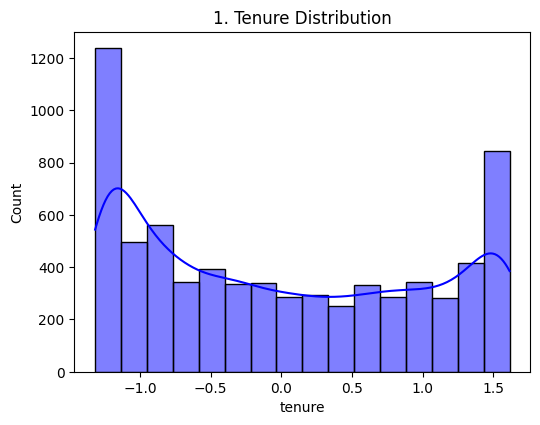

In [25]:
plt.figure(figsize=(20, 15))

plt.subplot(3, 3, 1)
sns.histplot(df['tenure'], kde=True, color='blue')
plt.title('1. Tenure Distribution')


Text(0.5, 1.0, '2. Monthly Charges Distribution')

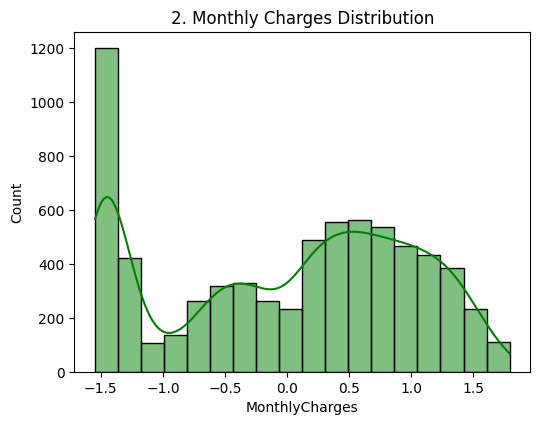

In [26]:
plt.figure(figsize=(20, 15))
plt.subplot(3, 3, 2)
sns.histplot(df['MonthlyCharges'], kde=True, color='green')
plt.title('2. Monthly Charges Distribution')


C:\Users\Technology Market\AppData\Local\Temp\ipykernel_5988\848161416.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='Set2')


Text(0.5, 1.0, '3. Churn vs No Churn Count')

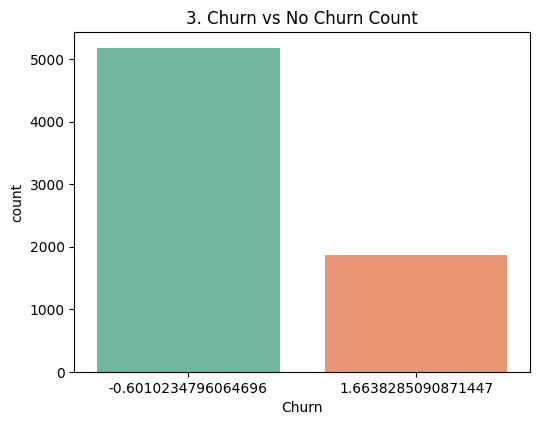

In [27]:
plt.figure(figsize=(20, 15))
plt.subplot(3, 3, 3)
sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('3. Churn vs No Churn Count')


C:\Users\Technology Market\AppData\Local\Temp\ipykernel_5988\234945516.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='Set3')


Text(0.5, 1.0, '4. Monthly Charges by Churn')

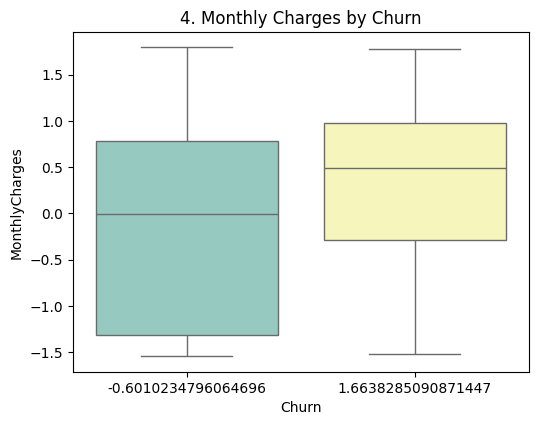

In [28]:
plt.figure(figsize=(20, 15))
plt.subplot(3, 3, 4)
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='Set3')
plt.title('4. Monthly Charges by Churn')


C:\Users\Technology Market\AppData\Local\Temp\ipykernel_5988\4285915732.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df, palette='Set1')


Text(0.5, 1.0, '5. Tenure by Churn')

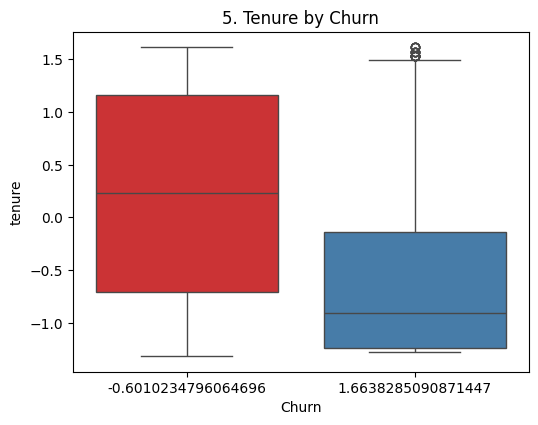

In [29]:
plt.figure(figsize=(20, 15))
plt.subplot(3, 3, 5)
sns.boxplot(x='Churn', y='tenure', data=df, palette='Set1')
plt.title('5. Tenure by Churn')


Text(0.5, 1.0, '6. Correlation Heatmap')

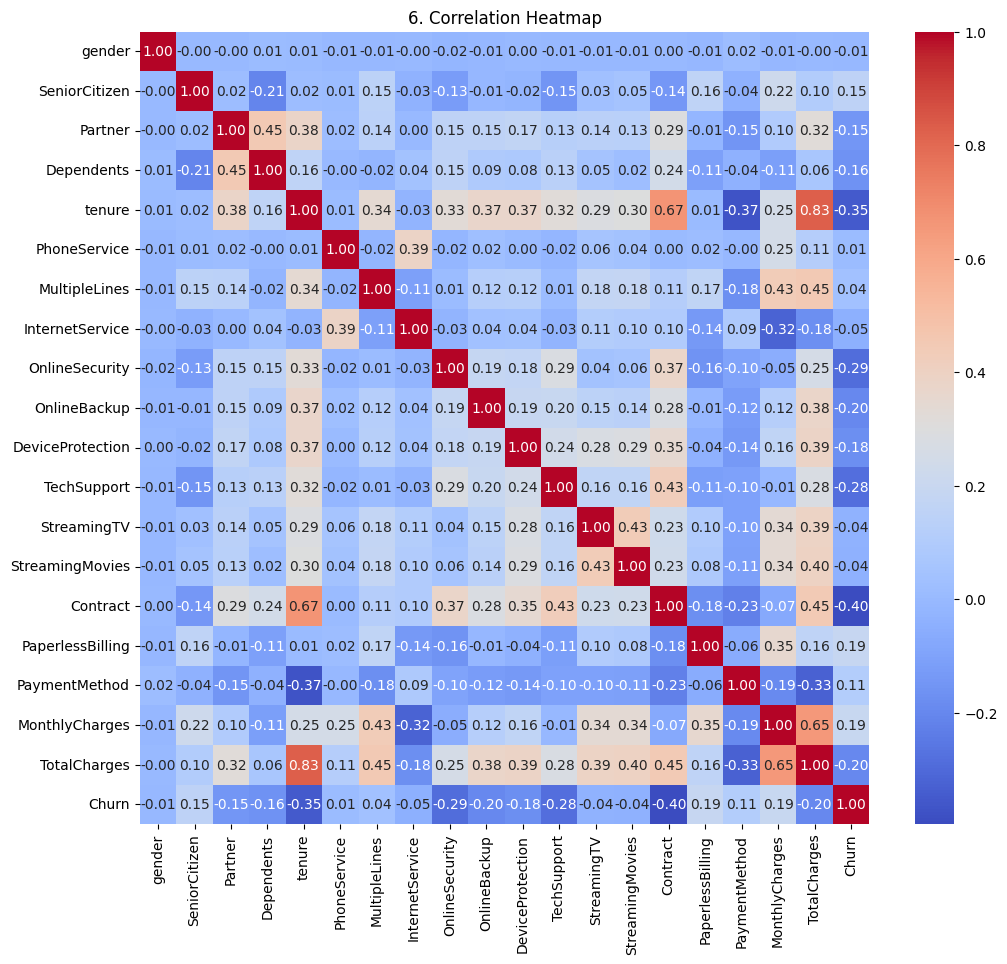

In [33]:
plt.figure(figsize=(40, 35))
plt.subplot(3, 3, 6)
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('6. Correlation Heatmap')


Text(0.5, 1.0, '7. CLTV Distribution')

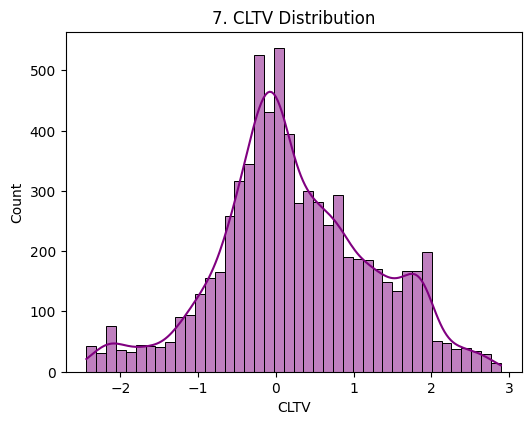

In [40]:
plt.figure(figsize=(20, 15))
plt.subplot(3, 3, 7)
sns.histplot(df['CLTV'], kde=True, color='purple')
plt.title('7. CLTV Distribution')



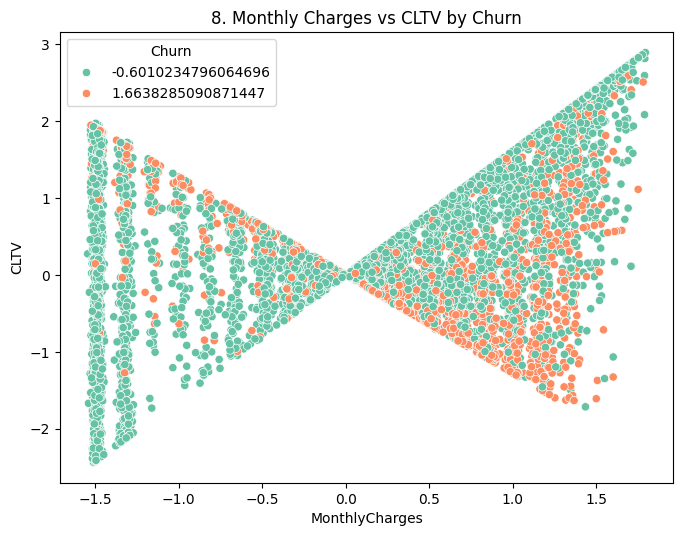

In [41]:
plt.figure(figsize=(20, 15))
plt.subplot(3, 3, 8)
sns.scatterplot(x='MonthlyCharges', y='CLTV', hue='Churn', data=df, palette='Set2')
plt.title('8. Monthly Charges vs CLTV by Churn')

plt.tight_layout()
plt.show()

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

X_reg = df.drop(columns=['CLTV', 'Churn'])
y_reg = df['CLTV']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train_reg, y_train_reg)
y_pred_lr = lr.predict(X_test_reg)

poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_reg)
X_test_poly = poly.transform(X_test_reg)
pr = LinearRegression()
pr.fit(X_train_poly, y_train_reg)
y_pred_pr = pr.predict(X_test_poly)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_reg, y_train_reg)
y_pred_ridge = ridge.predict(X_test_reg)

lasso = Lasso(alpha=0.1)
lasso.fit(X_train_reg, y_train_reg)
y_pred_lasso = lasso.predict(X_test_reg)


In [43]:

regression_results = {
    'Linear Regression': {'RMSE': np.sqrt(mean_squared_error(y_test_reg, y_pred_lr)), 'MAE': mean_absolute_error(y_test_reg, y_pred_lr), 'R2': r2_score(y_test_reg, y_pred_lr)},
    'Polynomial Regression': {'RMSE': np.sqrt(mean_squared_error(y_test_reg, y_pred_pr)), 'MAE': mean_absolute_error(y_test_reg, y_pred_pr), 'R2': r2_score(y_test_reg, y_pred_pr)},
    'Ridge Regression': {'RMSE': np.sqrt(mean_squared_error(y_test_reg, y_pred_ridge)), 'MAE': mean_absolute_error(y_test_reg, y_pred_ridge), 'R2': r2_score(y_test_reg, y_pred_ridge)},
    'Lasso Regression': {'RMSE': np.sqrt(mean_squared_error(y_test_reg, y_pred_lasso)), 'MAE': mean_absolute_error(y_test_reg, y_pred_lasso), 'R2': r2_score(y_test_reg, y_pred_lasso)}
}

regression_df = pd.DataFrame(regression_results).T
print(regression_df)

                               RMSE           MAE        R2
Linear Regression      1.054377e-01  6.713032e-02  0.989529
Polynomial Regression  1.932401e-15  1.514307e-15  1.000000
Ridge Regression       1.057836e-01  6.792809e-02  0.989460
Lasso Regression       7.207782e-01  5.705685e-01  0.510669


In [46]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [51]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from imblearn.over_sampling import SMOTE


In [52]:

if 'Churn' in df.columns:
    if df['Churn'].dtype == 'object':
        df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0}).fillna(0).astype(int)
    else:
        df['Churn'] = df['Churn'].astype(int)

X_clf = df.drop(columns=['Churn', 'CLTV'])
y_clf = df['Churn']

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_clf, y_train_clf)


In [53]:

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'SVM': SVC(probability=True),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'Naive Bayes': GaussianNB(),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

classification_results = []
for name, model in models.items():
    model.fit(X_train_smote, y_train_smote)
    y_pred = model.predict(X_test_clf)
    
    classification_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test_clf, y_pred),
        'Precision': precision_score(y_test_clf, y_pred),
        'Recall': recall_score(y_test_clf, y_pred),
        'F1': f1_score(y_test_clf, y_pred)
    })

clf_df = pd.DataFrame(classification_results)
print(clf_df)

best_model_name = clf_df.loc[clf_df['Recall'].idxmax()]['Model']
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test_clf)
cm = confusion_matrix(y_test_clf, y_pred_best)
print(f"Best Model based on Recall: {best_model_name}")
print("Confusion Matrix:\n", cm)

                 Model  Accuracy  Precision    Recall        F1
0  Logistic Regression  0.741661   0.508651  0.786096  0.617647
1                  SVM  0.748758   0.519608  0.708556  0.599548
2                  KNN  0.678495   0.434711  0.703209  0.537283
3        Decision Tree  0.721079   0.478161  0.556150  0.514215
4          Naive Bayes  0.727466   0.491525  0.775401  0.601660
5        Random Forest  0.774308   0.572539  0.590909  0.581579
6    Gradient Boosting  0.773598   0.559140  0.695187  0.619785
Best Model based on Recall: Logistic Regression
Confusion Matrix:
 [[751 284]
 [ 80 294]]


In [54]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score


In [55]:

seg_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
X_seg = df[seg_features]

scaler_seg = StandardScaler()
X_seg_scaled = scaler_seg.fit_transform(X_seg)

inertias = []
silhouettes = []
K_range = range(2, 11)


In [56]:

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_seg_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_seg_scaled, km.labels_))

best_k = K_range[np.argmax(silhouettes)]
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['KMeans_Cluster'] = km_final.fit_predict(X_seg_scaled)

db = DBSCAN(eps=0.5, min_samples=5)
df['DBSCAN_Cluster'] = db.fit_predict(X_seg_scaled)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_seg_scaled)


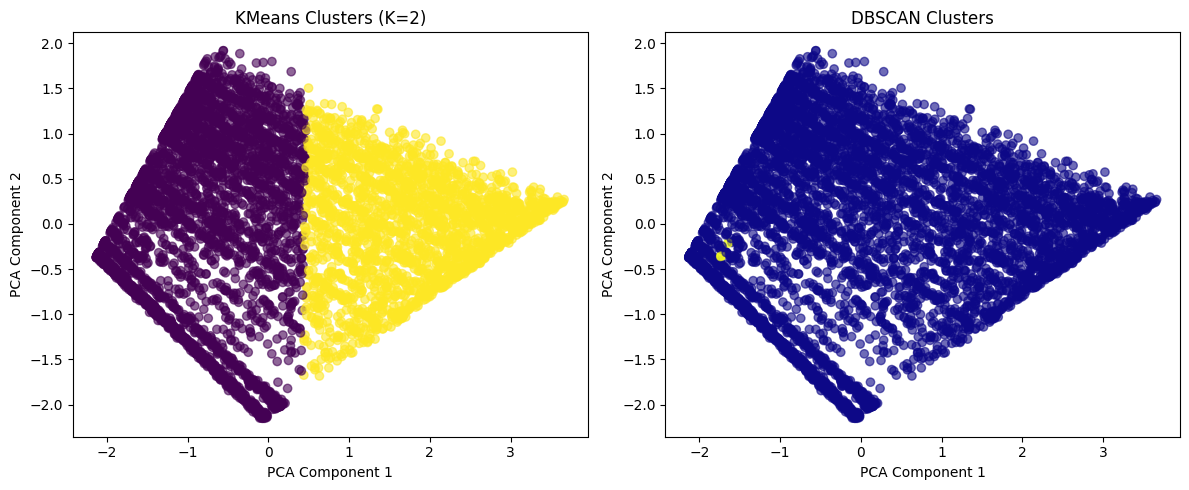

In [57]:

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['KMeans_Cluster'], cmap='viridis', alpha=0.6)
plt.title(f'KMeans Clusters (K={best_k})')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')

plt.subplot(1, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['DBSCAN_Cluster'], cmap='plasma', alpha=0.6)
plt.title('DBSCAN Clusters')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')

plt.tight_layout()
plt.show()

In [61]:
pip install streamlit

^C
Note: you may need to restart the kernel to use updated packages.
